[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 03 Hypothesis test
## - Parametric tests: 
- t-test
- F-test
- Pearson correlation tests


In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt

- load data from previous class, here we are going to use 

In [2]:
### load data
df = pd.read_csv("../Lecture02/n34_all.csv", parse_dates=["time"])
df["year"] = df["time"].dt.year
df

,time,nino34,year
0,1854-01-01,25.897331,1854
1,1854-02-01,26.055464,1854
2,1854-03-01,26.908459,1854
3,1854-04-01,27.631338,1854
4,1854-05-01,27.902256,1854
...,...,...,...
2067,2026-04-01,28.126972,2026
2068,2026-05-01,28.838810,2026
2069,2026-06-01,29.267714,2026
2070,2026-07-01,29.277988,2026


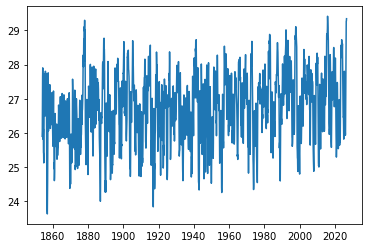

In [3]:
# ---- plot all the data --
plt.plot(df["time"],df["nino34"])

- Test whether the characteristics of Niño 3.4 in recent decades (1996–2025) have changed from the earlier period (1951–1980).


In [4]:
### organize the data 
### define the two period

early = df.loc[(df["year"] >= 1951) & (df["year"] <= 1980), "nino34"].values
recent = df.loc[(df["year"] >= 1996) & (df["year"] <= 2025), "nino34"].values

print("Early period 1951-1980: n =", len(early),
      "mean =", early.mean(), "std =", early.std(ddof=1))
print("Recent period 1996-2025: n =", len(recent),
      "mean =", recent.mean(), "std =", recent.std(ddof=1))


Early period 1951-1980: n = 360 mean = 26.743776250000003 std = 0.9123559696233714
Recent period 1996-2025: n = 360 mean = 26.995492416666668 std = 1.0238408991708086


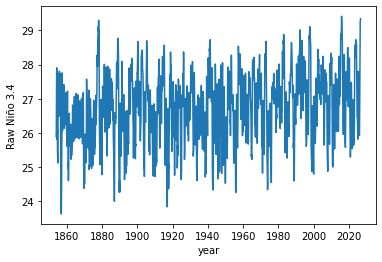

In [5]:
plt.plot(df['time'],df['nino34'])
plt.xlabel('year')
plt.ylabel('Raw Niño 3.4')
plt.savefig('nino34.png',dpi=200)

### 1. If mean has changed: Welch's t-test
scipy.stats.ttest_ind

In [6]:
t_stat, p_val = stats.ttest_ind(recent, early, equal_var=False)
print (f"Welch's t-test: {t_stat:.2f};", f"p-value: {p_val:.3g}")

Welch's t-test: 3.48; p-value: 0.000527


In [7]:
results=stats.ttest_ind(recent, early,equal_var=False)
results.statistic

3.482644213825185

### 2. If varainces from the two periods are the same: F-test

Scipy.stats doesn't offer F-test of equal variances, so we will do the calculation direclty.

$$
F = \dfrac{\sigma_1^2}{\sigma_2^2}
$$

In [8]:
# F-statistic
n1, n2 = len(recent), len(early)
sigma1, sigma2 = recent.var(ddof=1), early.var(ddof=1)
F = sigma1**2 / sigma2**2       # convention: larger-variance group in numerator is optional;
dfn, dfd = n1 - 1, n2 - 1      # here it's just recent/early as defined
print(f"F = {F:.4f}, df=({dfn},{dfd})")


F = 1.5859, df=(359,359)


We need to find the p-value given F and the degrees of freedom. But we don't know whether our observed value is on the left or right side, so let's check both and get the two-tailed p-value by doubling the smaller tail.

In [9]:
p_lower = stats.f.cdf(F, dfn, dfd)
p_upper = 1 - stats.f.cdf(F, dfn, dfd)
p_val = 2 * min(p_upper, p_lower)

print(f" p = {p_val:.4g}")


 p = 1.383e-05


### Correlation test

- use pearson

In [10]:
rho, p_scipy = stats.pearsonr(early, recent)
print(f" coreelation: {rho:.2f}, p = {p_scipy:.4g}")





 coreelation: 0.12, p = 0.02478


- We don't really need to calculate t-statistic here since stats function gives p-values already, but let's do it anyway....

$$
t = \dfrac{\rho\sqrt{n-2}}{\sqrt{1-r^2}}
$$

In [11]:
# get p values from t-statistic
df = len(early) - 2
t_stat = rho * np.sqrt(df / (1 - rho**2))
### two tails
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df))
print(f" t_stat: {t_stat:.2f}, p = {p_val:.4g}")


 t_stat: 2.25, p = 0.02478


--- back to the lecture 

### Hands on ###
- load and organize PRISM monthly temperature and precip data for Oregan 

In [12]:
df=pd.read_csv('PRISM_ppt_tmean_45.0000_-123.0000_189501_202607.csv')
df.columns = ['date', 'ppt', 'tmean']
df['year'] = df['date'].str[:4].astype(int)
df['month'] = df['date'].str[5:7].astype(int)



In [13]:
# Aggregate to annual: mean temperature, total precipitation
annual_temp = df.groupby('year')['tmean'].mean()
annual_ppt = df.groupby('year')['ppt'].sum()

### define the two period:
arg_early = np.argwhere((annual_temp.index>=1951) & (annual_temp.index<=1980)).ravel()
arg_recent = np.argwhere((annual_temp.index>=1996) & (annual_temp.index<=2025)).ravel()

t1 = annual_temp.values[arg_early]
t2 = annual_temp.values[arg_recent]
p1 = annual_ppt.values[arg_early]
p2 = annual_ppt.values[arg_recent]


## - Non-Parametric tests: Wilcoxon rank-sum, Kruskal–Wallis  and Kolmogorov–Smirnov 


In [29]:
### start by loading data and assign month and year. Here we are using Winter Niño3.4
df = pd.read_csv("../Lecture02/n34_all.csv", parse_dates=["time"])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df

,time,nino34,year,month
0,1951-01-01,25.254510,1951,1
1,1951-02-01,25.724410,1951,2
2,1951-03-01,26.911339,1951,3
3,1951-04-01,27.592520,1951,4
4,1951-05-01,27.926334,1951,5
...,...,...,...,...
902,2026-03-01,27.285143,2026,3
903,2026-04-01,28.127030,2026,4
904,2026-05-01,28.840480,2026,5
905,2026-06-01,29.268995,2026,6


In [51]:
# ---- Same two 30-year periods but only use data from December, January, and February ----
djf = df[df['month'].isin([12, 1, 2])].copy()
djf['djf_year'] = djf['year']
djf.loc[djf['month'] == 12, 'djf_year'] = djf['year'] + 1  # Dec belongs to following winter
djf

,time,nino34,year,month,djf_year
0,1951-01-01,25.254510,1951,1,1951
1,1951-02-01,25.724410,1951,2,1951
11,1951-12-01,26.915699,1951,12,1952
12,1952-01-01,26.674343,1952,1,1952
13,1952-02-01,26.751930,1952,2,1952
...,...,...,...,...,...
888,2025-01-01,25.815332,2025,1,2025
889,2025-02-01,26.332956,2025,2,2025
899,2025-12-01,25.928493,2025,12,2026
900,2026-01-01,25.970407,2026,1,2026


In [68]:
counts = djf.groupby('djf_year')['nino34'].count()
complete_years = counts[counts == 3].index  # keep only complete D-J-F triads

djf_seasonal = djf[djf['djf_year'].isin(complete_years)].groupby('djf_year')['nino34'].mean().reset_index()

# ---- Define the two periods ----
early = djf_seasonal.loc[(djf_seasonal["djf_year"] >= 1951) & (djf_seasonal["djf_year"] <= 1980), "nino34"].values
recent = djf_seasonal.loc[(djf_seasonal["djf_year"] >= 1996) & (djf_seasonal["djf_year"] <= 2025), "nino34"].values


In [69]:


nX, nY = len(early), len(recent)
N = nX + nY

### - Wilcoxon rank-sum

In [79]:
### Combining data and get rank-sum
combined = np.concatenate([early, recent])
ranks = stats.rankdata(combined)
RX = ranks[:nX].sum() 
RY = ranks[nX:].sum() 
print('Rx:', RX, 'RY:,',RY)

Rx: 876.0 RY:, 894.0


In [81]:
### Expected value and Variance of Rx
E_RX = nX * (N + 1) / 2                   
var_RX = nX * nY * (N + 1) / 12 

### continuity correction
C = -0.5 if RX > E_RX else 0.5            
z_cor = (RX - E_RX + C) / np.sqrt(var_RX)
p_val = 2 * (1 - stats.norm.cdf(abs(z_cor)))
print ('E(RX), VAR(RX)',E_RX,var_RX)
print('Z_coor',z_cor, 'p-value',p_val)

E(RX), VAR(RX) 870.0 4350.0
Z_coor 0.08339078479367938 p-value 0.9335408156603096


In [82]:
np.sqrt(4350)

65.95452979136459

Couple notes for python coding:
- z_stat, p_val = stats.ranksums(early, recent): No apply continuity correction, so you got z_stat and p-value different to the mannual claculation
- u_stat, p_value = stats.mannwhitneyu: same as Willson rank-sum test, so you receive the same p-value but this funciton output $U_x$
$U_x = R_x-N_x(N_x+1)/2$

In [75]:
u_stat, p_value = stats.mannwhitneyu(early, recent, alternative='two-sided')
print('mannwhitneyu U_stat',u_stat, 'p-value',p_value)

mannwhitneyu U_stat 441.0 p-value 0.9335408156603096


In [76]:
z_stat, p_val = stats.ranksums(early, recent)
print (z_stat, p_val)

0.09097176522946841 0.927515026089144


### - Kolmogorov-Smirnov (KS) test:ks_2samp

In [77]:
# ---- KS two-sample test (built-in scipy function) ----
D_stat, p_val = stats.ks_2samp(early, recent)
print (D_stat, p_val)

0.12758620689655173 0.9277751406890471


### - kruskal Wallis
H_stat, p_value = stats.kruskal(group1, group2, group3, ...)
We will practice this later

In [1]:
"""
Run this LOCALLY to download NASA GISTEMP global mean temperature anomaly
(annual, land+ocean) and save a clean CSV to upload back to Claude.

Requirements: pandas, requests (pip install pandas requests)
"""
import pandas as pd
import requests
import io

URL = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

print("Downloading NASA GISTEMP global mean temperature data...")
resp = requests.get(URL, timeout=60)
resp.raise_for_status()

# GISTEMP CSV has one header/title row before the real column headers
raw = pd.read_csv(io.StringIO(resp.text), skiprows=1)

# Column "J-D" = annual (Jan-Dec) mean anomaly in hundredths of a degC (as text, some "***")
df = raw[["Year", "J-D"]].copy()
df.columns = ["year", "gmt_anomaly"]
df["gmt_anomaly"] = pd.to_numeric(df["gmt_anomaly"], errors="coerce")
df = df.dropna().reset_index(drop=True)
df["year"] = df["year"].astype(int)

df.to_csv("gmt_annual_anomaly.csv", index=False)
print(df.tail(10))


     year  gmt_anomaly
136  2016         1.01
137  2017         0.92
138  2018         0.85
139  2019         0.98
140  2020         1.01
141  2021         0.85
142  2022         0.89
143  2023         1.17
144  2024         1.28
145  2025         1.19


In [14]:
"""
Kruskal-Wallis test: are Atlantic TC counts conditioned on ENSO phase?

H0: TC counts have the same distribution across El Nino, Neutral, La Nina
H1: at least one group's distribution differs
"""

import pandas as pd
from scipy import stats

# --- Load data ---
df = pd.read_csv("hurricane_counts_by_enso.csv")

# --- Split into the three ENSO groups ---
el_nino = df.loc[df.enso_phase == "El Nino", "hurricane_count"]
neutral = df.loc[df.enso_phase == "Neutral", "hurricane_count"]
la_nina = df.loc[df.enso_phase == "La Nina", "hurricane_count"]

print(f"n (El Nino, Neutral, La Nina) = {len(el_nino)}, {len(neutral)}, {len(la_nina)}")
print(f"medians = {el_nino.median()}, {neutral.median()}, {la_nina.median()}")

# --- Kruskal-Wallis H-test ---
H, p = stats.kruskal(el_nino, neutral, la_nina)

print(f"\nKruskal-Wallis H statistic = {H:.4f}")
print(f"degrees of freedom = {3 - 1}")
print(f"p-value = {p:.6f}")

alpha = 0.05
if p < alpha:
    print(f"\np < {alpha}: reject H0 -> TC counts differ significantly across ENSO phases")
else:
    print(f"\np >= {alpha}: fail to reject H0 -> no significant difference detected")

,year,hurricane_count
0,1951,12
1,1952,11
2,1953,14
3,1954,16
4,1955,13
...,...,...
71,2022,14
72,2023,20
73,2024,19
74,2025,13


In [22]:
"""
Kruskal-Wallis test: are Atlantic TC counts conditioned on ENSO phase?

H0: TC counts have the same distribution across El Nino, Neutral, La Nina
H1: at least one group's distribution differs
"""

import pandas as pd
from scipy import stats

# --- Load data ---
df = pd.read_csv("../hurricane_counts_by_enso.csv")

# --- Split into the three ENSO groups ---
el_nino = df.loc[df.enso_phase == "El Nino", "hurricane_count"]
neutral = df.loc[df.enso_phase == "Neutral", "hurricane_count"]
la_nina = df.loc[df.enso_phase == "La Nina", "hurricane_count"]

print(f"n (El Nino, Neutral, La Nina) = {len(el_nino)}, {len(neutral)}, {len(la_nina)}")
print(f"medians = {el_nino.median()}, {neutral.median()}, {la_nina.median()}")

# --- Kruskal-Wallis H-test ---
H, p = stats.kruskal(el_nino, neutral, la_nina)

print(f"\nKruskal-Wallis H statistic = {H:.4f}")
print(f"degrees of freedom = {3 - 1}")
print(f"p-value = {p:.6f}")

alpha = 0.05
if p < alpha:
    print(f"\np < {alpha}: reject H0 -> TC counts differ significantly across ENSO phases")
else:
    print(f"\np >= {alpha}: fail to reject H0 -> no significant difference detected")

n (El Nino, Neutral, La Nina) = 21, 33, 21
medians = 10.0, 13.0, 14.0

Kruskal-Wallis H statistic = 14.3211
degrees of freedom = 2
p-value = 0.000777

p < 0.05: reject H0 -> TC counts differ significantly across ENSO phases


In [24]:
#--- F-test for equal variances ---
# By convention, put the larger variance in the numerator
if la_nina.var() > el_nino.var():
    F = la_nina.var() / el_nino.var()
    dfn, dfd = len(la_nina) - 1, len(el_nino) - 1
else:
    F = el_nino.var() / la_nina.var()
    dfn, dfd = len(el_nino) - 1, len(la_nina) - 1
 
p_f = 2 * min(stats.f.cdf(F, dfn, dfd), 1 - stats.f.cdf(F, dfn, dfd))
print(f"\nF-test: F = {F:.4f} (df1={dfn}, df2={dfd}), p = {p_f:.4f}")
 
equal_var = p_f >= 0.05
print(f"-> {'Fail to reject' if equal_var else 'Reject'} equal-variance assumption at alpha=0.05")
 
# --- t-test ---
# Student's t-test (equal variance assumed)
t_eq, p_eq = stats.ttest_ind(el_nino, la_nina, equal_var=True)
print(f"\nStudent's t-test (equal variance assumed): t = {t_eq:.4f}, p = {p_eq:.6f}")
 
# Welch's t-test (does not assume equal variance)
t_w, p_w = stats.ttest_ind(el_nino, la_nina, equal_var=False)
print(f"Welch's t-test (unequal variance):        t = {t_w:.4f}, p = {p_w:.6f}")
 
# --- Conclusion using the appropriate t-test based on the F-test result ---
t_final, p_final = (t_eq, p_eq) if equal_var else (t_w, p_w)
alpha = 0.05
print(f"\nUsing {'Student' if equal_var else 'Welch'}'s t-test result (per F-test above):")
if p_final < alpha:
    print(f"p = {p_final:.6f} < {alpha}: reject H0 -> means differ significantly")
else:
    print(f"p = {p_final:.6f} >= {alpha}: fail to reject H0 -> no significant difference in means")


F-test: F = 1.9074 (df1=20, df2=20), p = 0.1574
-> Fail to reject equal-variance assumption at alpha=0.05

Student's t-test (equal variance assumed): t = -3.4295, p = 0.001416
Welch's t-test (unequal variance):        t = -3.4295, p = 0.001517

Using Student's t-test result (per F-test above):
p = 0.001416 < 0.05: reject H0 -> means differ significantly
